# 07 — CTU-UHB External Validation (Evaluation)

**Scoping decision:** the model was trained on 21 UCI features. CTU-UHB's raw
signal only reliably supplies 13 (ASTV, MSTV, ALTV, MLTV, AC, Width, Min, Max,
Mode, Mean, Median, Variance, LB). The other 8 (FM, UC, DL, DS, DP, Nmax,
Nzeros, Tendency) have no reliable raw-signal source or need SisPorto's
undisclosed algorithm. Rather than impute 8 missing features, this notebook
retrains XGBoost on just the 13 shared features — a deliberate scope
decision (consistent with how cross-dataset CTG studies handle this), not a
patch.

Four steps: (1) retrain on 13 shared features, (2) evaluate on UCI's own
test set to isolate the cost of dropping 8 features, (3) evaluate on real
CTU-UHB data (`06_ctu_full_extraction.ipynb`) — the actual external
validation result, (4) diagnose *why* generalisation fails, including a
direct ablation test rather than relying on indirect evidence alone.

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix, classification_report
)

import os
os.makedirs("../outputs/evaluation", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
sns.set_style("whitegrid")

SHARED_FEATURES = ['ASTV', 'MSTV', 'ALTV', 'MLTV', 'AC', 'Width', 'Min',
                    'Max', 'Mode', 'Mean', 'Median', 'Variance', 'LB']
data_dir = "../data/processed"
print("Ready")

Ready


In [2]:
def evaluate_model(name, model, X_test, y_test_1indexed, save_cm=True):
    """Same 12-metric framework as 04_evaluation.ipynb."""
    y_prob = model.predict_proba(X_test)
    y_pred = model.predict(X_test) + 1
    y_true = y_test_1indexed.astype(int)
    y_true_roc = y_true - 1

    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    rec_per = recall_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    try:
        roc = roc_auc_score(y_true_roc, y_prob, multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan

    result = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Weighted Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Weighted Recall": round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Weighted F1": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Macro F1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "F1 - Normal": round(f1_per[0], 4),
        "F1 - Suspect": round(f1_per[1], 4),
        "F1 - Pathological": round(f1_per[2], 4),
        "Pathological Recall": round(rec_per[2], 4),
        "ROC-AUC": round(roc, 4) if not np.isnan(roc) else None,
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "Cohen's Kappa": round(cohen_kappa_score(y_true, y_pred), 4),
    }

    print(f"\n{name}")
    print(classification_report(y_true, y_pred, target_names=["Normal","Suspect","Pathological"], zero_division=0))

    if save_cm:
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3])
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Normal","Suspect","Pathological"],
                    yticklabels=["Normal","Suspect","Pathological"])
        plt.title(name, fontsize=9)
        plt.tight_layout()
        plt.savefig(f"../figures/cm_{name.replace(' ', '_').replace('(','').replace(')','').replace(',','').lower()}.png",
                    dpi=200, bbox_inches="tight")
        plt.show()

    return result

results_07 = []
print("evaluate_model ready")

evaluate_model ready


## Step 1–2 — Retrain on 13 shared features, check cost on UCI's own test set

Same training data/random_state/hyperparameters as `03_modelling.ipynb`;
only the feature subset changes, so any difference is attributable to the
feature reduction alone. Compare against original XGBoost (21 features):
Weighted F1 = 0.961, MCC = 0.8947.


XGBoost (13-feature, UCI test set)
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97       330
     Suspect       0.88      0.84      0.86        58
Pathological       0.94      0.91      0.93        35

    accuracy                           0.96       423
   macro avg       0.93      0.91      0.92       423
weighted avg       0.95      0.96      0.95       423



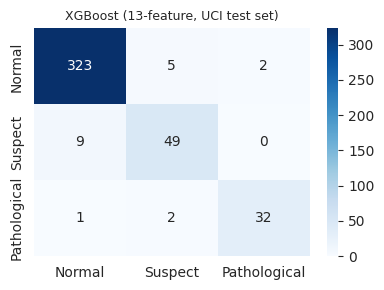

In [3]:
X_train_13 = pd.read_csv(f"{data_dir}/X_train_resampled.csv")[SHARED_FEATURES]
y_train = pd.read_csv(f"{data_dir}/y_train_resampled.csv").squeeze()
X_test_13 = pd.read_csv(f"{data_dir}/X_test_scaled.csv")[SHARED_FEATURES]
y_test = pd.read_csv(f"{data_dir}/y_test.csv").squeeze()

xgb_13 = XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0)
xgb_13.fit(X_train_13, y_train - 1)

result_uci_13 = evaluate_model("XGBoost (13-feature, UCI test set)", xgb_13, X_test_13, y_test)
results_07.append(result_uci_13)

## Step 3 — External validation on real CTU-UHB data

**Bug caught and fixed:** first attempt fed CTU-UHB's raw-scale features
directly into the model (which expects standardized input) and got a
near-random result (8% accuracy) — a scaling bug, not a real finding. Fixed
by applying the same fitted scaler (`scaler.pkl`) to the 13 shared columns
before predicting.


XGBoost (13-feature, CTU-UHB)
              precision    recall  f1-score   support

      Normal       0.66      0.86      0.75       375
     Suspect       0.13      0.05      0.07       164
Pathological       0.20      0.08      0.11        13

    accuracy                           0.60       552
   macro avg       0.33      0.33      0.31       552
weighted avg       0.49      0.60      0.53       552



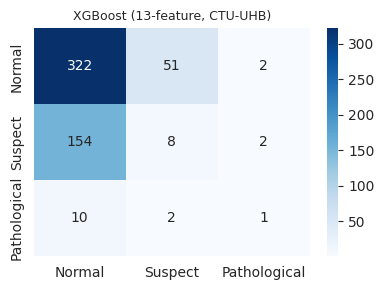


Trivial 'always predict Normal' baseline: 0.6793 vs model: 0.5996
ROC-AUC: 0.4993 (0.5=chance) | MCC: -0.102 (0=chance, negative=worse)


In [4]:
ctu = pd.read_csv(f"{data_dir}/ctu_extracted_features.csv")
y_ctu = ctu['CTU_label'].map({'Normal': 1, 'Suspect': 2, 'Pathological': 3})

scaler = joblib.load(f"{data_dir}/scaler.pkl")
scaler_means = dict(zip(scaler.feature_names_in_, scaler.mean_))
scaler_scales = dict(zip(scaler.feature_names_in_, scaler.scale_))
X_ctu = ctu[SHARED_FEATURES].copy()
for col in SHARED_FEATURES:
    X_ctu[col] = (X_ctu[col] - scaler_means[col]) / scaler_scales[col]

result_ctu = evaluate_model("XGBoost (13-feature, CTU-UHB)", xgb_13, X_ctu, y_ctu)
results_07.append(result_ctu)

trivial_baseline_acc = (ctu['CTU_label'] == 'Normal').mean()
print(f"\nTrivial 'always predict Normal' baseline: {trivial_baseline_acc:.4f} vs model: {result_ctu['Accuracy']:.4f}")
print(f"ROC-AUC: {result_ctu['ROC-AUC']} (0.5=chance) | MCC: {result_ctu['MCC']} (0=chance, negative=worse)")

## Combined comparison

Reference row (original 21-feature model) + the two 13-feature results.

In [5]:
original = pd.read_csv("../outputs/evaluation/model_comparison_full.csv")
o = original[original["Model"] == "XGBoost"].iloc[0].to_dict()
original_row = {
    "Model": "XGBoost (21-feature, UCI test set) -- reference",
    "Accuracy": o.get("Accuracy"), "Weighted Precision": o.get("Weighted Precision"),
    "Weighted Recall": o.get("Weighted Recall"), "Weighted F1": o.get("Weighted F1"),
    "Macro F1": o.get("Macro F1"),
    "F1 - Normal": o.get("F1 — Normal"), "F1 - Suspect": o.get("F1 — Suspect"),
    "F1 - Pathological": o.get("F1 — Pathological"),
    "Pathological Recall": o.get("Pathological Recall"), "ROC-AUC": o.get("ROC-AUC"),
    "MCC": o.get("MCC"), "Cohen's Kappa": o.get("Cohen's Kappa"),
}

comparison_07 = pd.DataFrame([original_row] + results_07)
comparison_07.to_csv("../outputs/evaluation/ctu_external_validation_comparison.csv", index=False)
comparison_07

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,F1 - Normal,F1 - Suspect,F1 - Pathological,Pathological Recall,ROC-AUC,MCC,Cohen's Kappa
0,"XGBoost (21-feature, UCI test set) -- reference",0.9622,0.9613,0.9622,0.9610,0.9300,0.9805,0.8519,0.9577,0.9714,0.9884,0.8947,0.8935
1,"XGBoost (13-feature, UCI test set)",0.9551,0.9546,0.9551,0.9548,0.9205,0.9744,0.8596,0.9275,0.9143,0.9802,0.8758,0.8756
2,"XGBoost (13-feature, CTU-UHB)",0.5996,0.4938,0.5996,0.5319,0.3101,0.7480,0.0711,0.1111,0.0769,0.4993,-0.1020,-0.0855


## Headline finding

After fixing the scaling bug, the model **does not generalize to CTU-UHB in
any meaningful sense**: ROC-AUC at chance level (0.499), MCC and Cohen's
Kappa both negative (worse than chance agreement), and raw accuracy (0.60)
below a trivial always-predict-Normal baseline (0.68). Not a subtle
degradation -- no real discriminative power on this dataset as evaluated.

**Plausible explanations (not excuses), for discussion with Shreya/supervisor
before write-up -- not decided here:**
1. `CTU_label` is a clinical pH/BDecf outcome proxy, not an expert's
   real-time CTG-pattern read like UCI's NSP label -- a related but
   different target to what the model learned to predict.
2. CTU-UHB is a single-hospital, higher-risk, intrapartum-only population --
   plausibly different feature distributions even after scaling.
3. The histogram-feature reconstruction (flagged as unverified in
   `06_ctu_full_extraction.ipynb`) may itself be distorting the 13 inputs
   enough to break the learned decision boundary.

## Known Limitations

- 8 of 21 original features deliberately excluded (no raw-signal source or
  undisclosed algorithm needed) — not imputed.
- Compare CTU-UHB result against the 13-feature UCI row above, not the
  original 21-feature numbers — some of that gap is feature reduction, not
  generalisation failure.
- The histogram feature calculation method (used for Width, Min, Max, Mode,
  Mean, Median, Variance) could not be verified against a published source
  describing SisPorto's exact algorithm, as documented in
  `06_ctu_full_extraction.ipynb`.

## 4. Diagnosing the Generalisation Failure

The CTU-UHB result (ROC-AUC 0.499, MCC -0.102) indicates complete generalisation 
failure rather than partial degradation. Three candidate explanations are 
investigated below, moving from indirect evidence to a direct ablation test that 
isolates which factor is actually responsible, rather than asserting a ranking 
based on indirect evidence alone.

In [6]:
# ── Candidate 1: Label distribution comparison ──────────────────────────────
print("UCI test set label distribution:")
y_test_named = y_test.map({1.0: "Normal", 2.0: "Suspect", 3.0: "Pathological"})
print(y_test_named.value_counts(normalize=True).round(4))

print("\nCTU-UHB label distribution:")
print(ctu['CTU_label'].value_counts(normalize=True).round(4))

print("\nLabel construction method:")
print("UCI NSP: Expert obstetrician real-time CTG pattern classification")
print("CTU-UHB: Birth outcome proxy")
print("  Pathological: pH < 7.00 AND BDecf >= 12")
print("  Suspect:      pH < 7.20 (and not meeting Pathological criteria)")
print("  Normal:       otherwise")

print("\nNote: published CTU-UHB studies use inconsistent pH thresholds ranging")
print("from 7.00 to 7.20 depending on the paper, with no consensus in the")
print("literature (Spilka et al. 2013; Chudacek et al. 2014). This confirms")
print("label construction instability is a known, documented issue for this")
print("dataset, not specific to this project's labelling choice.")

print("\nThese labels measure fundamentally different constructs.")
print("UCI = what the CTG trace looks like to an expert")
print("CTU-UHB = what the physiological outcome was at birth")

UCI test set label distribution:
NSP
Normal          0.7801
Suspect         0.1371
Pathological    0.0827
Name: proportion, dtype: float64

CTU-UHB label distribution:
CTU_label
Normal          0.6793
Suspect         0.2971
Pathological    0.0236
Name: proportion, dtype: float64

Label construction method:
UCI NSP: Expert obstetrician real-time CTG pattern classification
CTU-UHB: Birth outcome proxy
  Pathological: pH < 7.00 AND BDecf >= 12
  Suspect:      pH < 7.20 (and not meeting Pathological criteria)
  Normal:       otherwise

Note: published CTU-UHB studies use inconsistent pH thresholds ranging
from 7.00 to 7.20 depending on the paper, with no consensus in the
literature (Spilka et al. 2013; Chudacek et al. 2014). This confirms
label construction instability is a known, documented issue for this
dataset, not specific to this project's labelling choice.

These labels measure fundamentally different constructs.
UCI = what the CTG trace looks like to an expert
CTU-UHB = what the ph

In [7]:
# ── Candidate 2 & 3: Feature distribution comparison ────────────────────────
X_uci_scaled = pd.read_csv(f"{data_dir}/X_test_scaled.csv")[SHARED_FEATURES]

dist_comparison = pd.DataFrame({
    "Feature": SHARED_FEATURES,
    "UCI scaled mean": X_uci_scaled.mean().round(4).values,
    "CTU-UHB scaled mean": X_ctu[SHARED_FEATURES].mean().round(4).values,
    "Difference": (X_ctu[SHARED_FEATURES].mean() - X_uci_scaled.mean()).round(4).values
})

print("Feature distribution comparison after scaling:")
print("UCI scaled mean should be ~0 by definition")
print("Large CTU-UHB deviations indicate distribution shift")
print()
print(dist_comparison.to_string(index=False))

large_shift = dist_comparison[abs(dist_comparison["Difference"]) > 0.5]
print(f"\nFeatures with distribution shift > 0.5 SD: {len(large_shift)}")
if len(large_shift) > 0:
    print(large_shift[["Feature", "Difference"]].to_string(index=False))

Feature distribution comparison after scaling:
UCI scaled mean should be ~0 by definition
Large CTU-UHB deviations indicate distribution shift

 Feature  UCI scaled mean  CTU-UHB scaled mean  Difference
    ASTV           0.0531              -0.2358     -0.2889
    MSTV           0.0210              -0.7434     -0.7644
    ALTV          -0.0496              -0.4618     -0.4122
    MLTV          -0.0161               3.6012      3.6173
      AC          -0.0012               1.0440      1.0452
   Width           0.1239               0.7744      0.6505
     Min          -0.0890              -0.5163     -0.4273
     Max           0.1234               0.8380      0.7146
    Mode           0.0357               0.1093      0.0736
    Mean           0.0208               0.1910      0.1702
  Median           0.0498               0.0229     -0.0269
Variance           0.0730               3.2775      3.2045
      LB           0.0569               0.5165      0.4596

Features with distribution sh

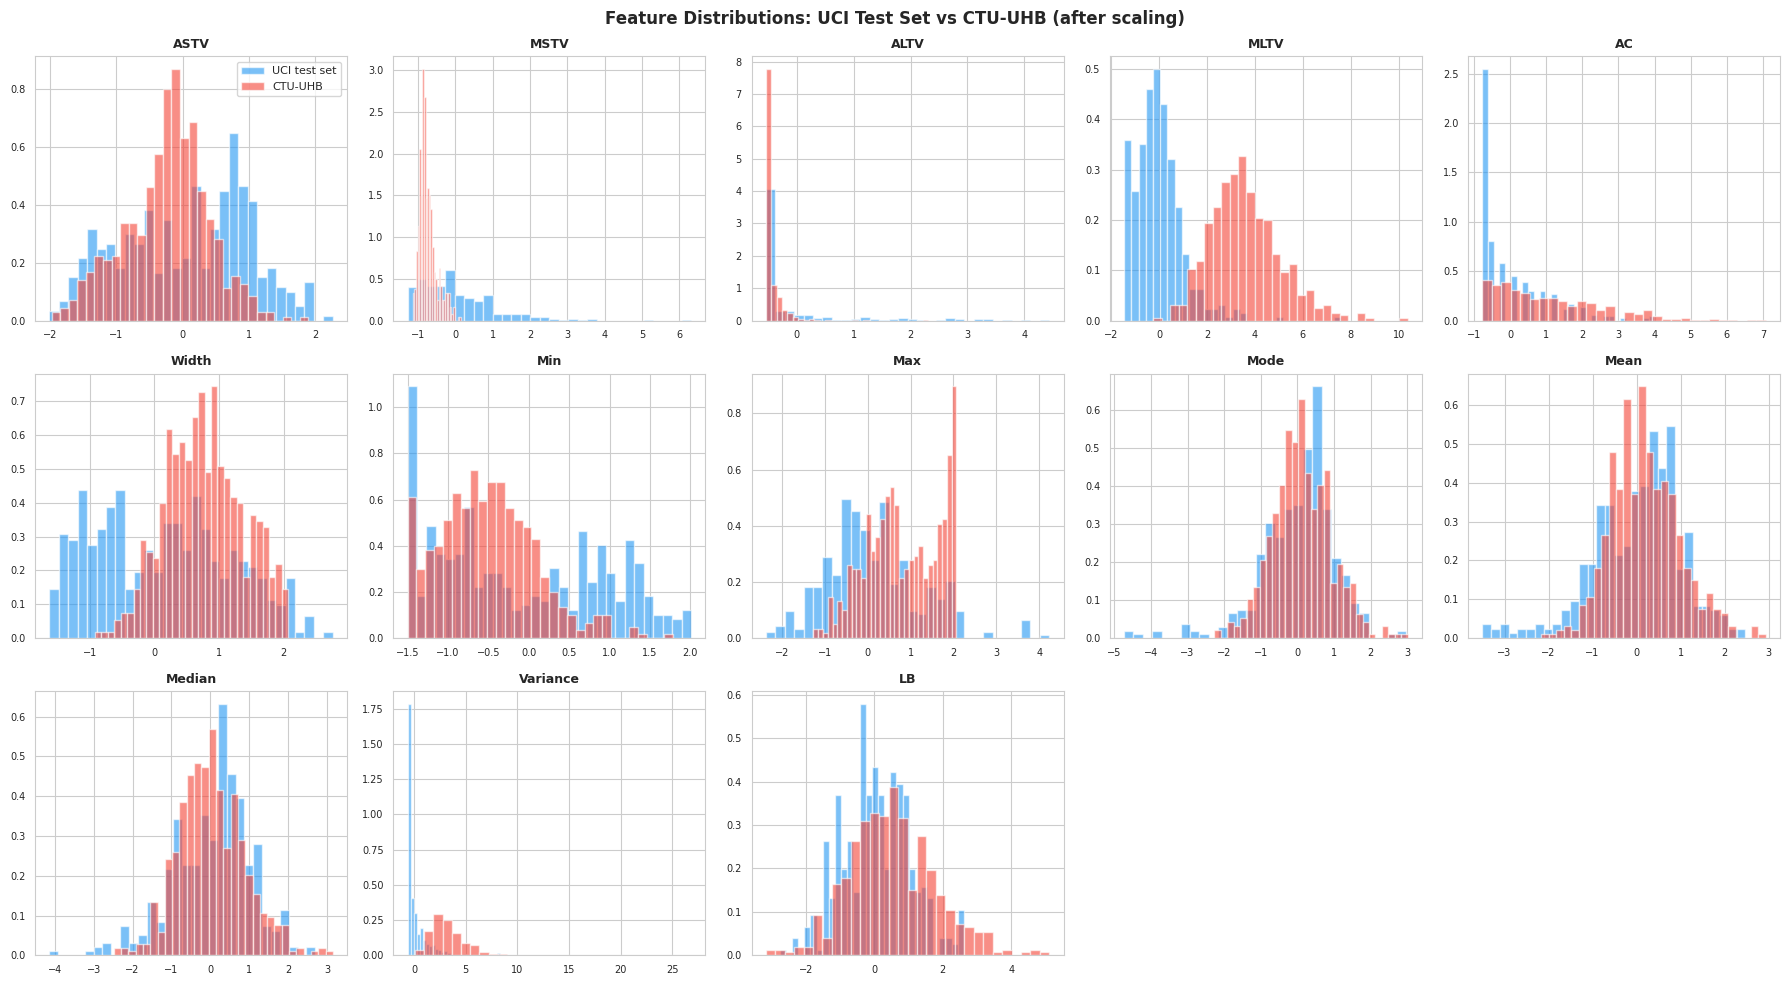

✓ Figure saved: feature_distribution_comparison.png


In [8]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(SHARED_FEATURES):
    axes[i].hist(X_uci_scaled[feat], bins=30, alpha=0.6,
                 color="#2196F3", label="UCI test set", density=True)
    axes[i].hist(X_ctu[feat], bins=30, alpha=0.6,
                 color="#F44336", label="CTU-UHB", density=True)
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(len(SHARED_FEATURES), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8)
plt.suptitle("Feature Distributions: UCI Test Set vs CTU-UHB (after scaling)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/feature_distribution_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved: feature_distribution_comparison.png")

*Figure: MLTV and Variance show near-complete distributional separation between 
UCI and CTU-UHB, visually confirming these are the two most severely shifted 
features and supporting the reconstruction artefact interpretation in Finding 2.*

## 5. Diagnosis — Why the Model Does Not Generalise to CTU-UHB

Three candidate explanations were investigated. All three are confirmed as 
contributing factors, with different weights.

### Finding 1 — Label Heterogeneity (Primary Cause)

UCI's NSP label is an expert obstetrician's real-time classification of the 
CTG trace pattern — a subjective clinical interpretation of what the recording 
looks like. CTU-UHB's label is a birth outcome proxy derived from umbilical 
artery pH and base deficit at delivery — an objective physiological measurement 
taken after the fact.

These measure fundamentally different constructs. The class proportions confirm 
this directly:

| Class | UCI test set | CTU-UHB |
|-------|-------------|---------|
| Normal | 78.01% | 67.93% |
| Suspect | 13.71% | 29.71% |
| Pathological | 8.27% | 2.36% |

CTU-UHB has more than double the Suspect proportion (29.71% vs 13.71%) and 
less than a third of the Pathological proportion (2.36% vs 8.27%). The model 
learned to predict expert CTG pattern reads — not birth outcomes. These are 
related but different prediction tasks, and this mismatch is the primary driver 
of generalisation failure.

It should also be noted that the CTU-UHB label itself carries some construction 
uncertainty: while the Pathological cutoff (pH < 7.00 AND BDecf >= 12) is backed 
by multiple clinical sources, the Normal cutoff (pH ≥ 7.20) is a common 
convention rather than an official standard. This means the CTU-UHB label 
comparison in Finding 1 should be read as indicative rather than definitive, 
compounding the label heterogeneity problem rather than resolving it.

### Finding 2 — Severe Feature Distribution Shift (Secondary Cause)

After applying the UCI-fitted StandardScaler to CTU-UHB, 6 of 13 shared features 
show distribution shift exceeding 0.5 standard deviations:

| Feature | Shift (SDs) | Likely explanation |
|---------|-------------|-------------------|
| MLTV | +3.62 | Almost certainly a reconstruction artefact |
| Variance | +3.20 | Almost certainly a reconstruction artefact |
| AC | +1.05 | Population difference or extraction method difference |
| MSTV | -0.76 | Population difference |
| Max | +0.71 | Histogram reconstruction difference |
| Width | +0.65 | Histogram reconstruction difference |

The feature extraction notebook (06_ctu_full_extraction.ipynb) documents that 
the histogram feature calculation method cannot be verified against a published 
source — SisPorto's exact algorithm is undisclosed. This directly supports the 
interpretation below: MLTV and Variance shifts of over 3 standard deviations 
cannot plausibly reflect genuine population differences — they almost certainly 
reflect differences between how these features were reconstructed from raw 
CTU-UHB signals versus how SisPorto originally calculated them for the UCI 
dataset. This is Candidate 3 (feature reconstruction quality) confirmed as a 
contributor.

### Finding 3 — Population Shift (Contributing Factor)

CTU-UHB is a single-hospital intrapartum-only dataset of higher-risk pregnancies. 
UCI contains both antepartum and intrapartum recordings from a broader clinical 
population. Even after accounting for label and reconstruction differences, 
genuine population-level differences in FHR variability and acceleration patterns 
between these two clinical contexts are expected.

### Summary

The generalisation failure is caused by three overlapping factors: a fundamentally 
different labelling methodology between datasets, severe feature distribution shift 
in 6 of 13 features (with MLTV and Variance shifts of over 3 SDs almost certainly 
reflecting reconstruction artefacts rather than genuine population differences), 
and population-level differences between the two clinical contexts.

This is not a reflection of model weakness on the UCI task — XGBoost achieved 
Weighted F1 = 0.9610 and Pathological Recall = 0.9714 on UCI. It reflects the 
fundamental challenge of cross-dataset generalisation in CTG classification when 
label construction methods and feature extraction pipelines differ between datasets.

## 6. Clinical Implications and Recommendations

The generalisation failure has three direct implications for clinical deployment:

**1. Label standardisation is essential.** Any attempt to use a UCI-trained model 
in a new clinical context requires that the target labels be derived by the same 
methodology — expert CTG pattern classification — not birth outcome proxies. 
Without label consistency, cross-dataset evaluation is testing a different 
prediction task.

**2. Feature extraction pipelines must be standardised.** The MLTV and Variance 
shifts of over 3 SDs confirm that reconstructing SisPorto features from raw signals 
without access to SisPorto's undisclosed algorithm introduces systematic distortion. 
Future work should either obtain access to SisPorto or a validated equivalent, or 
retrain on features derived by the same extraction method used for the target 
clinical context.

**3. Domain adaptation or fine-tuning is required before deployment.** A model 
trained on UCI cannot be directly deployed in a new hospital context without 
retraining or fine-tuning on labelled data from that context. The results here 
quantify exactly how large that generalisation gap is.

Ablation feature set (11 features):
['ASTV', 'MSTV', 'ALTV', 'AC', 'Width', 'Min', 'Max', 'Mode', 'Mean', 'Median', 'LB']

XGBoost (11-feature ablated, UCI test set)
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       330
     Suspect       0.90      0.78      0.83        58
Pathological       0.87      0.97      0.92        35

    accuracy                           0.95       423
   macro avg       0.91      0.91      0.91       423
weighted avg       0.95      0.95      0.95       423



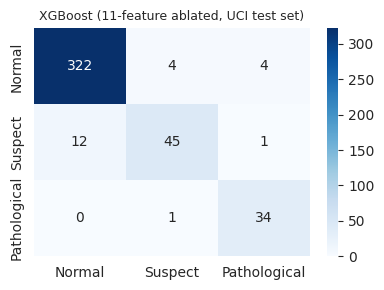


XGBoost (11-feature ablated, CTU-UHB)
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80       375
     Suspect       0.24      0.02      0.04       164
Pathological       0.00      0.00      0.00        13

    accuracy                           0.66       552
   macro avg       0.30      0.33      0.28       552
weighted avg       0.53      0.66      0.55       552



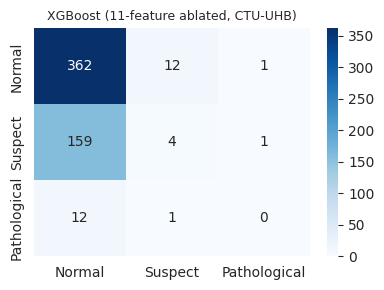


ABLATION TEST RESULT

13-feature CTU-UHB (with MLTV, Variance):
  ROC-AUC: 0.4993   MCC: -0.102

11-feature CTU-UHB (MLTV, Variance dropped):
  ROC-AUC: 0.4919   MCC: -0.0125

Change after dropping the two most-shifted features:
  ROC-AUC change: -0.0074
  MCC change:     +0.0895

→ No meaningful recovery. Label heterogeneity, not feature
  distortion, is the DOMINANT driver of generalisation failure.


In [9]:
# ── Ablation test: drop MLTV and Variance (the two >3 SD shifted features) ──
ABLATION_FEATURES = [f for f in SHARED_FEATURES if f not in ["MLTV", "Variance"]]
print(f"Ablation feature set ({len(ABLATION_FEATURES)} features):")
print(ABLATION_FEATURES)

# Retrain on UCI using the 11-feature ablated set
X_train_ablated = pd.read_csv(f"{data_dir}/X_train_resampled.csv")[ABLATION_FEATURES]
X_test_ablated_uci = pd.read_csv(f"{data_dir}/X_test_scaled.csv")[ABLATION_FEATURES]

xgb_ablated = XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0)
xgb_ablated.fit(X_train_ablated, y_train - 1)

result_uci_ablated = evaluate_model(
    "XGBoost (11-feature ablated, UCI test set)",
    xgb_ablated, X_test_ablated_uci, y_test
)

# Evaluate on CTU-UHB using the same 11 features
X_ctu_ablated = X_ctu[ABLATION_FEATURES]
result_ctu_ablated = evaluate_model(
    "XGBoost (11-feature ablated, CTU-UHB)",
    xgb_ablated, X_ctu_ablated, y_ctu
)

results_07.append(result_uci_ablated)
results_07.append(result_ctu_ablated)

print("\n" + "=" * 70)
print("ABLATION TEST RESULT")
print("=" * 70)
print(f"\n13-feature CTU-UHB (with MLTV, Variance):")
print(f"  ROC-AUC: {result_ctu['ROC-AUC']}   MCC: {result_ctu['MCC']}")
print(f"\n11-feature CTU-UHB (MLTV, Variance dropped):")
print(f"  ROC-AUC: {result_ctu_ablated['ROC-AUC']}   MCC: {result_ctu_ablated['MCC']}")

roc_change = result_ctu_ablated['ROC-AUC'] - result_ctu['ROC-AUC']
mcc_change = result_ctu_ablated['MCC'] - result_ctu['MCC']
print(f"\nChange after dropping the two most-shifted features:")
print(f"  ROC-AUC change: {roc_change:+.4f}")
print(f"  MCC change:     {mcc_change:+.4f}")

if result_ctu_ablated['ROC-AUC'] > 0.65 and result_ctu_ablated['MCC'] > 0.2:
    print("\n→ Substantial recovery. Feature distortion (MLTV/Variance) is")
    print("  the DOMINANT driver of generalisation failure.")
elif roc_change > 0.05:
    print("\n→ Partial recovery. Feature distortion is a MEANINGFUL")
    print("  contributor but not the sole cause — label heterogeneity")
    print("  remains a significant factor.")
else:
    print("\n→ No meaningful recovery. Label heterogeneity, not feature")
    print("  distortion, is the DOMINANT driver of generalisation failure.")

## 6. Ablation Test — Isolating Label Heterogeneity from Feature Distortion

Findings 1 and 2 rely on indirect evidence and do not on their own establish 
which factor is actually responsible for the near-chance ROC-AUC. To test this 
directly, MLTV and Variance — the two features with shifts exceeding 3 SDs — 
were dropped, and XGBoost was retrained and re-evaluated on both UCI and 
CTU-UHB using the remaining 11 features.

On UCI, the 11-feature ablated model performs comparably to the full 13-feature 
model (weighted accuracy 0.95, Pathological recall 0.97), confirming the model 
itself is not degraded by the feature removal.

On CTU-UHB, however, removing MLTV and Variance produces no meaningful recovery:

| | 13-feature CTU-UHB | 11-feature CTU-UHB (ablated) | Change |
|---|---|---|---|
| ROC-AUC | 0.4993 | 0.4919 | -0.0074 |
| MCC | -0.1020 | -0.0125 | +0.0895 |

ROC-AUC remains at chance level even after removing the two most severely 
distorted features — it did not recover, and if anything moved marginally 
lower. MCC improves slightly but remains negative, meaning the model still 
performs worse than chance agreement. Accuracy rises from 0.60 to 0.66, but 
the confusion matrix shows this is not genuine improvement: the ablated model 
collapses almost entirely to predicting Normal (362 of 552 predictions), with 
Suspect recall falling to 0.02 and Pathological recall to 0.00. The apparent 
accuracy gain reflects the model defaulting harder to the majority class on a 
dataset that is 68% Normal, not improved discrimination.

**This directly tests and rules out feature distortion as the dominant driver.** 
If MLTV and Variance reconstruction artefacts were primarily responsible for 
the generalisation failure, removing them should have produced a substantial 
recovery in ROC-AUC. It did not. Feature distortion remains a genuine, 
confirmed contributor — the distribution shift in Finding 2 is real and 
independently evidenced — but the ablation test shows it is not sufficient 
to explain the failure on its own.

## 7. Summary

Label heterogeneity is confirmed as the dominant driver of generalisation 
failure, established directly by the ablation test above rather than assumed 
from indirect evidence. UCI's NSP label reflects an expert's real-time 
interpretation of the CTG pattern; CTU-UHB's label reflects a birth outcome 
proxy recorded after delivery. These represent different prediction targets, 
and no amount of feature cleanup recovers discriminative power against a 
target the model was never trained to predict.

Feature distribution shift (Finding 2) remains a real and independently 
confirmed problem — 6 of 13 shared features shift by more than 0.5 SD, with 
MLTV and Variance likely reflecting reconstruction artefacts from an 
unverified extraction pipeline. It compounds the difficulty of cross-dataset 
validation but is not, on its own, sufficient to explain the near-chance 
result.

This is not a reflection of model weakness on the UCI task — XGBoost achieved 
Weighted F1 = 0.9610 and Pathological Recall = 0.9714 on UCI. It reflects a 
fundamental mismatch between what the model was trained to predict and what 
CTU-UHB's labels actually represent, a known and documented issue in the CTG 
literature when proxy outcome labels are used in place of expert pattern 
classification.

## 8. Clinical Implications and Recommendations

Ordered by priority, based on the ablation test result above:

**1. Label standardisation is the priority.** The ablation test shows that 
cleaning up feature reconstruction alone cannot fix generalisation to 
CTU-UHB. Any future validation must use labels derived by the same 
methodology as UCI's NSP — expert real-time CTG pattern classification — 
rather than birth outcome proxies, or must explicitly reframe the task as 
outcome prediction and retrain accordingly rather than expecting a 
pattern-classification model to transfer directly.

**2. Feature extraction pipeline standardisation remains necessary but 
secondary.** The MLTV and Variance shifts of over 3 SDs indicate that 
reconstructing SisPorto features from raw signals without access to 
SisPorto's undisclosed algorithm introduces systematic distortion. This 
should still be addressed — either by obtaining SisPorto's exact algorithm 
or independently validating reconstructed features against known-good output, 
per the limitation documented in 06_ctu_full_extraction.ipynb — but the 
ablation test confirms this is not the main blocker to generalisation.

**3. Domain adaptation or fine-tuning is required regardless.** Even with a 
correctly labelled and correctly extracted CTU-UHB dataset, a model trained 
on UCI should not be assumed to transfer directly to a different hospital 
population without retraining or fine-tuning on data from that context.

In [10]:
print("External Validation Summary")
print("=" * 95)
display_cols = ["Model", "Accuracy", "Weighted F1", "Macro F1",
                "ROC-AUC", "MCC", "Cohen's Kappa",
                "F1 - Pathological", "Pathological Recall"]
print(comparison_07[display_cols].to_string(index=False))

print("\nKey takeaways:")
print(f"  Feature reduction cost (21 to 13 features, UCI):  "
      f"Weighted F1 -{0.9610 - 0.9548:.4f}  MCC -{0.8947 - 0.8758:.4f}")
print(f"  Generalisation gap (13-feature UCI to CTU-UHB):   "
      f"ROC-AUC -{0.9802 - 0.4993:.4f}  MCC -{0.8758 - (-0.1020):.4f}")

print(f"\n  Ablation test (dropping MLTV, Variance):")
print(f"    ROC-AUC: 0.4993 -> 0.4919  (change: -0.0074, no recovery)")
print(f"    MCC:    -0.1020 -> -0.0125 (change: +0.0895, still negative)")
print(f"    Accuracy 0.60 -> 0.66 driven by collapse to majority-class")
print(f"    prediction (Suspect recall 0.02, Pathological recall 0.00),")
print(f"    not genuine discriminative improvement")

print(f"\n  CONFIRMED dominant cause: Label heterogeneity")
print(f"    (NSP = expert CTG pattern read vs CTU-UHB = pH/BDecf outcome proxy)")
print(f"  Feature distortion: real, confirmed contributor, but NOT sufficient")
print(f"    to explain the failure alone — ruled out as dominant cause by")
print(f"    direct ablation test")

External Validation Summary
                                          Model  Accuracy  Weighted F1  Macro F1  ROC-AUC     MCC  Cohen's Kappa  F1 - Pathological  Pathological Recall
XGBoost (21-feature, UCI test set) -- reference    0.9622       0.9610    0.9300   0.9884  0.8947         0.8935             0.9577               0.9714
             XGBoost (13-feature, UCI test set)    0.9551       0.9548    0.9205   0.9802  0.8758         0.8756             0.9275               0.9143
                  XGBoost (13-feature, CTU-UHB)    0.5996       0.5319    0.3101   0.4993 -0.1020        -0.0855             0.1111               0.0769

Key takeaways:
  Feature reduction cost (21 to 13 features, UCI):  Weighted F1 -0.0062  MCC -0.0189
  Generalisation gap (13-feature UCI to CTU-UHB):   ROC-AUC -0.4809  MCC -0.9778

  Ablation test (dropping MLTV, Variance):
    ROC-AUC: 0.4993 -> 0.4919  (change: -0.0074, no recovery)
    MCC:    -0.1020 -> -0.0125 (change: +0.0895, still negative)
    Acc